# 2026 Player Value Prediction Report

This notebook turns the predictive modeling work into a usable decision-support report. It trains models on historical player-season data, then uses 2025 production and multi-year player history to create 2026 projections.

The report now includes four layers:

1. Predicted 2026 value score.
2. Probability the player has a qualifying 2026 season.
3. Practical confidence and uncertainty labels.
4. Plain-English driver notes for interpretation.

## Why This Version Is Stronger

Earlier versions predicted a next-season value score only for players who already had a next-season outcome in the training data. That is useful, but it creates survivorship bias because players who disappear from the dataset are not fully represented in the regression target.

This version separates the problem into two questions:

- **Availability model:** Is the player likely to have a qualifying 2026 season?
- **Value model:** If he has a qualifying season, what value score does the model expect?

That makes the report more honest: a player can have a high upside projection but still carry availability risk.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")


def find_project_root(expected_file="data/processed/player_value_scores_2016_2025.csv"):
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / expected_file).exists():
            return candidate
    raise FileNotFoundError(f"Could not find {expected_file} from {Path.cwd()}")

project_root = find_project_root()
sys.path.insert(0, str(project_root / "src"))

from prediction_report import build_2026_prediction_tables

project_root

PosixPath('/Users/kylelevesque/Desktop/nfl-player-value-analysis-1')

## Generate Prediction Tables

This cell creates the model-ready player-season dataset, adds multi-year history features, trains the value and availability models, predicts 2026 outcomes from 2025 inputs, and saves report tables under `outputs/tables/`.

In [2]:
outputs = build_2026_prediction_tables(project_root=project_root, save_outputs=True)

player_predictions = outputs["player_predictions"]
team_summary = outputs["team_summary"]
position_summary = outputs["position_summary"]
top_players = outputs["top_players"]
low_confidence = outputs["low_confidence"]
value_validation_by_position = outputs["value_validation_by_position"]
availability_metrics = outputs["availability_validation_metrics"]
model_notes = outputs["model_notes"]
output_dir = outputs["output_dir"]

print("Player predictions:", player_predictions.shape)
print("Team summary:", team_summary.shape)
print("Position summary:", position_summary.shape)
print("Value validation by position:", value_validation_by_position.shape)
print("Output directory:", output_dir)


Player predictions: (501, 38)
Team summary: (32, 12)
Position summary: (4, 12)
Value validation by position: (4, 7)
Output directory: /Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables


## Top 2026 Player Projections

`predicted_2026_value_score` is the main model projection. `predicted_2026_qualifying_probability` estimates whether the player is likely to have a qualifying 2026 season. `availability_adjusted_2026_value` combines the two into a rough risk-adjusted projection.

In [3]:
display(
    player_predictions[[
        "player_display_name", "position", "primary_team_2025", "games_played_2025",
        "value_score_2025", "value_score_last2_avg", "predicted_2026_value_score",
        "predicted_2026_qualifying_probability", "availability_risk_level",
        "predicted_2026_value_tier", "confidence_level", "prediction_driver"
    ]].head(20)
)

,player_display_name,position,primary_team_2025,games_played_2025,value_score_2025,value_score_last2_avg,predicted_2026_value_score,predicted_2026_qualifying_probability,availability_risk_level,predicted_2026_value_tier,confidence_level,prediction_driver
4434,Amon-Ra St. Brown,WR,DET,17,2.403415,3.467191,2.344719,0.952970,Low,Elite,Medium,strong 2025 value; strong recent multi-year va...
4270,George Kittle,TE,SF,11,2.530436,4.169735,2.326808,0.698405,Medium,Elite,Low,strong 2025 value; strong recent multi-year va...
4324,Josh Allen,QB,BUF,16,1.792685,2.668903,2.005931,0.928390,Low,Elite,Medium,strong 2025 value; strong recent multi-year va...
4427,Ja'Marr Chase,WR,CIN,16,1.627635,2.714256,1.850496,0.938533,Low,Elite,Medium,strong 2025 value; strong recent multi-year va...
4577,Puka Nacua,WR,LA,16,6.045016,2.415654,1.692446,0.958105,Low,Elite,Medium,strong 2025 value; strong recent multi-year va...
4487,Trey McBride,TE,ARI,17,4.421011,1.530043,1.544206,0.936564,Low,Elite,Medium,strong 2025 value; strong recent multi-year va...
4360,A.J. Brown,WR,PHI,15,1.214140,2.466886,1.539393,0.916613,Low,Elite,Medium,strong 2025 value; strong recent multi-year va...
4573,Sam LaPorta,TE,DET,9,1.915858,2.120003,1.483344,0.801667,Low,Elite,Low,strong 2025 value; strong recent multi-year va...
4429,DeVonta Smith,WR,PHI,17,2.308108,1.606773,1.363847,0.951605,Low,Elite,Medium,strong 2025 value; strong recent multi-year va...
4459,George Pickens,WR,DAL,17,4.125910,0.745228,1.360158,0.963888,Low,Elite,Medium,strong 2025 value; durable recent sample; wide...


## Value Model Performance by Position

The value model is pooled across positions, with `position` included as a feature. This table checks whether rolling-validation error is materially different for QBs, RBs, WRs, and TEs.

If one position has much higher RMSE or clear positive/negative bias, that is evidence that a future version should test separate position-specific models.


,position,validation_rows,mean_actual_next_value,mean_predicted_next_value,bias,mae,rmse
0,QB,208,0.197644,0.196775,0.000869,0.661913,0.871971
1,RB,439,-0.029910,-0.036297,0.006387,0.735027,1.017361
2,TE,390,0.084142,0.008354,0.075788,0.650579,0.904336
3,WR,725,0.108454,0.181577,-0.073123,0.648695,0.885820


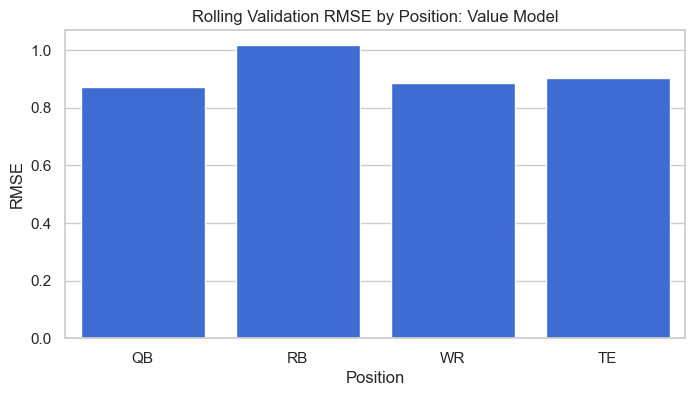

In [4]:
display(value_validation_by_position)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=value_validation_by_position,
    x="position",
    y="rmse",
    order=["QB", "RB", "WR", "TE"],
    color="#2563EB"
)
plt.title("Rolling Validation RMSE by Position: Value Model")
plt.xlabel("Position")
plt.ylabel("RMSE")
plt.show()


## Availability Model Performance

The availability model is a classifier. It estimates the probability that a player will have a qualifying next-season row. This partially addresses survivorship bias by making availability risk visible instead of silently excluding it.

,accuracy,brier_score,positive_rate,roc_auc,valid_year
0,0.712810,0.189968,0.723140,0.756119,2020
1,0.698990,0.186263,0.717172,0.779115,2021
2,0.732365,0.187736,0.709544,0.766124,2022
3,0.724731,0.169983,0.752688,0.821043,2023
4,0.707368,0.177306,0.768421,0.799352,2024


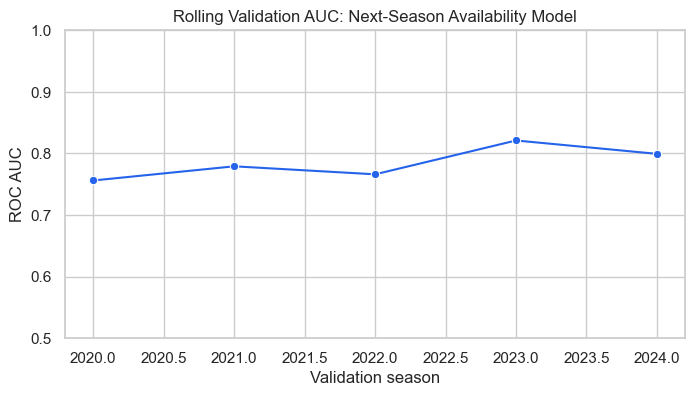

In [5]:
display(availability_metrics)

plt.figure(figsize=(8, 4))
sns.lineplot(
    data=availability_metrics,
    x="valid_year",
    y="roc_auc",
    marker="o",
    color="#2563EB"
)
plt.ylim(0.5, 1.0)
plt.title("Rolling Validation AUC: Next-Season Availability Model")
plt.xlabel("Validation season")
plt.ylabel("ROC AUC")
plt.show()

## Confidence and Risk Labels

Confidence and availability risk are intentionally separate:

- `availability_risk_level` asks whether the player is likely to have a qualifying next season.
- `confidence_level` asks whether the projection range is relatively stable.
- `prediction_driver` gives a short reason code for the projection.

This is more interpretable for higher-ups because the model no longer compresses every concern into one vague confidence label.

,availability_risk_level,confidence_level,players
0,High,High,18
1,High,Low,44
2,High,Medium,177
3,Low,High,13
4,Low,Low,9
5,Low,Medium,126
6,Medium,High,20
7,Medium,Low,30
8,Medium,Medium,64


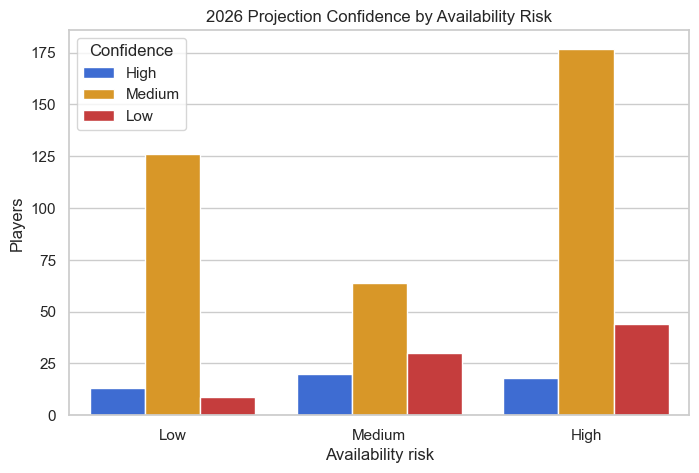

In [6]:
summary_counts = (
    player_predictions
    .groupby(["availability_risk_level", "confidence_level"], as_index=False)
    .agg(players=("player_id", "count"))
)

display(summary_counts)

plt.figure(figsize=(8, 5))
sns.countplot(
    data=player_predictions,
    x="availability_risk_level",
    hue="confidence_level",
    order=["Low", "Medium", "High"],
    hue_order=["High", "Medium", "Low"],
    palette={"High": "#2563EB", "Medium": "#F59E0B", "Low": "#DC2626"}
)
plt.title("2026 Projection Confidence by Availability Risk")
plt.xlabel("Availability risk")
plt.ylabel("Players")
plt.legend(title="Confidence")
plt.show()

## Team and Position Views

The team field is `primary_team_2025`, which is the team with the largest 2025 sample for the player. This should not be interpreted as a guaranteed 2026 roster projection.

In [7]:
display(team_summary.head(15))
display(position_summary)

,primary_team_2025,players,avg_predicted_2026_value_score,avg_availability_adjusted_2026_value,avg_qualifying_probability,median_predicted_2026_value_score,avg_confidence_score,high_confidence_players,high_availability_risk_players,elite_or_above_avg_players,top_projected_player,top_projected_value_score
10,DET,15,0.429808,0.422438,0.549876,0.215519,53.080000,0,7,10,Amon-Ra St. Brown,2.344719
3,BUF,15,0.211790,0.209908,0.684001,0.006616,54.806667,1,6,5,Josh Allen,2.005931
5,CHI,14,0.200427,0.213433,0.661962,0.220368,56.964286,1,6,8,Colston Loveland,1.140493
11,GB,16,0.186835,0.175179,0.665739,0.172918,54.681250,4,6,7,Tucker Kraft,1.181539
28,SF,14,0.183943,0.144902,0.593380,0.040187,54.071429,2,3,4,George Kittle,2.326808
21,NE,16,0.144789,0.173356,0.602636,0.059779,52.318750,0,6,5,Stefon Diggs,0.938432
15,KC,13,0.120508,0.135387,0.634695,0.048950,55.753846,2,3,4,Travis Kelce,1.125450
2,BAL,16,0.112006,0.132218,0.571180,0.000567,52.906250,2,9,6,Zay Flowers,1.253072
16,LA,14,0.110194,0.123086,0.687065,-0.071692,59.142857,2,5,4,Puka Nacua,1.692446
9,DEN,15,0.105938,0.114061,0.629257,0.090571,56.253333,2,7,4,Bo Nix,1.080384


,position,players,avg_predicted_2026_value_score,avg_availability_adjusted_2026_value,avg_qualifying_probability,median_predicted_2026_value_score,avg_confidence_score,high_confidence_players,high_availability_risk_players,low_confidence_players,top_projected_player,top_projected_value_score
0,QB,62,0.115456,0.183304,0.579648,-0.086522,47.393548,0,29,26,Josh Allen,2.005931
1,RB,124,0.020888,0.007940,0.561574,0.044286,54.862097,8,62,17,TreVeyon Henderson,0.620720
3,WR,205,-0.006084,0.093015,0.577074,-0.171520,57.171707,24,97,24,Amon-Ra St. Brown,2.344719
2,TE,110,-0.042593,0.047199,0.567662,-0.180843,58.779091,19,51,16,George Kittle,2.326808


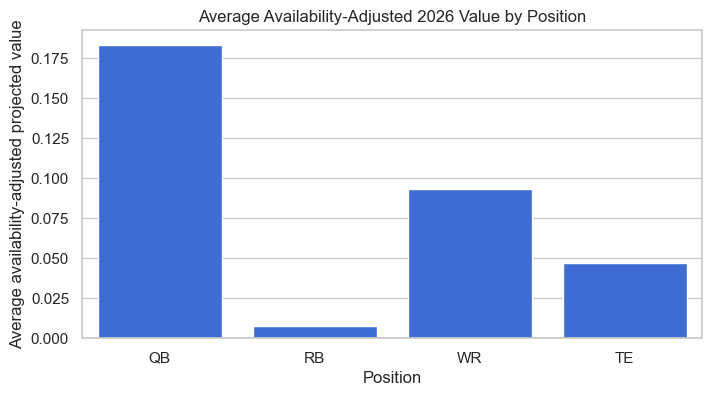

In [8]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=position_summary,
    x="position",
    y="avg_availability_adjusted_2026_value",
    color="#2563EB"
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Average Availability-Adjusted 2026 Value by Position")
plt.xlabel("Position")
plt.ylabel("Average availability-adjusted projected value")
plt.show()

## Exported Files

The notebook saves CSV and JSON outputs that feed the Excel workbook. The workbook includes filters, summary tabs, model notes, data dictionary, confidence labels, availability risk, and prediction drivers.

In [9]:
for path in sorted(output_dir.glob("2026_*")):
    print(path)

/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/2026_availability_validation_metrics.csv
/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/2026_availability_validation_predictions.csv
/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/2026_low_confidence_predictions.csv
/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/2026_player_value_predictions.csv
/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/2026_player_value_predictions.xlsx
/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/2026_position_summary.csv
/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/2026_prediction_data_dictionary.csv
/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/2026_prediction_model_notes.json
/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/2026_prediction_report_tables.json
/Users/kylelevesque/Desktop/nfl-player-v

## Methodological Notes

This report is a screening and prioritization tool, not a guarantee. It is stronger than the first version because it adds multi-year player history, tunes the final enhanced-history feature set directly, separates availability from value, and reports value-model error by position.

Important limitations remain:

- It does not know future injuries, depth-chart changes, coaching changes, rookies, free agency, or 2026 team context.
- EPA-based production reflects team environment and usage, not pure individual talent.
- The model is still pooled across positions; position-level validation helps monitor this, but it does not fully replace separate position-specific models.
- `availability_adjusted_2026_value` is a rough risk-adjusted summary, while `predicted_2026_value_score` and `predicted_2026_qualifying_probability` should be interpreted separately.
